**Dynamic Optimization**

April 22, 2026


In [1]:
include("./lotka.jl")
include("./dynopt_sensitivity.jl")
include("./dynopt_rk.jl")

using LinearAlgebra
using Plots
using Interpolations
using .lotka
using .dynopt_sensitivity
using .dynopt_rk


Lotka-Volterra population dynamics model
$$\begin{align*}
\dot{x}_1(t) &= x_1(t)(p_1-x_2(t)),\qquad t\in[t_0,t_\text{f}] \\
\dot{x}_2(t) &= -x_2(t)(p_2-x_1(t)), \\
x_1(t_0) &= s_{0,1} \\
x_2(t_0) &= s_{0,2} \\
\end{align*}$$

In [2]:
model = LotkaIVP()

IVPStruct(2, 2, Main.lotka.lotka_f, Main.lotka.lotka_dfdx, Main.lotka.lotka_dfdp, Main.lotka.lotka_fadj)

## Complex-step perturbed trajectories

This uses the augmentation of the right hand side f by `NX` many copies and solves the nominal IVP along with `NX` IVPs for initial values that have been
perturbed in the imaginary component. Careful when using transpositions `'`. These become complex conjugates -- you don't want that. Use `transpose` instead.

We run these computations first since they're easy to implement and yield extremely precise results. We'll use them as references and compare all other approaches against them.

In [3]:
pert = 1.0e-20
x0 = [1.0, 1.0]
p0 = [1.1, 0.9]
x0_aug = augmentComplexStepIv(x0, pert)
W_ref = []

for prec in 1:5
    eta, _, _ = rungeKutta(
        (t,x) -> augmentComplexStepRhs(x->model.f(t,x,p0), x, model.nx), 
            x0_aug, 0.0, 30.0, 10.0^(-prec), RK4)

    W = hcat([ imag(eta[ i*model.nx+1 : (i+1)*model.nx ])/pert  
               for i in 1:model.nx ]...)

    println("\nAt h=$(10.0^(-prec)):")
    println("Final state = ",eta[1:model.nx])
    println("Complex-step perturbed final sensitivity = ",W)

    push!(W_ref, W)
end


At h=0.1:
Final state = ComplexF64[0.8112401351401309 + 0.0im, 0.9952468945934765 + 0.0im]
Complex-step perturbed final sensitivity = [-0.03391619656553085 0.8837153915192221; -0.9148286855049265 0.031448916756562105]

At h=0.010000000000000002:
Final state = ComplexF64[0.811242050817131 + 0.0im, 0.99524456885247 + 0.0im]
Complex-step perturbed final sensitivity = [-0.03389841113413931 0.8837185191184518; -0.9148286590233328 0.03146999035850049]

At h=0.001:
Final state = ComplexF64[0.8112420510247091 + 0.0im, 0.995244568637797 + 0.0im]
Complex-step perturbed final sensitivity = [-0.03389840933677095 0.8837185192793082; -0.9148286588797355 0.03146999246871023]

At h=0.0001:
Final state = ComplexF64[0.8112420510259027 + 0.0im, 0.9952445686365493 + 0.0im]
Complex-step perturbed final sensitivity = [-0.033898409326500206 0.8837185192802288; -0.9148286588790271 0.03146999248091807]

At h=1.0e-5:
Final state = ComplexF64[0.811242051025991 + 0.0im, 0.9952445686365315 + 0.0im]
Complex-step p

In [4]:
W_ref

5-element Vector{Any}:
 [-0.03391619656553085 0.8837153915192221; -0.9148286855049265 0.031448916756562105]
 [-0.03389841113413931 0.8837185191184518; -0.9148286590233328 0.03146999035850049]
 [-0.03389840933677095 0.8837185192793082; -0.9148286588797355 0.03146999246871023]
 [-0.033898409326500206 0.8837185192802288; -0.9148286588790271 0.03146999248091807]
 [-0.03389840932647714 0.8837185192801246; -0.9148286588790894 0.031469992481005106]

## Real-perturbed trajectories

In [ ]:
# This takes ~2 minutes on my M1Pro but only 56s on my M4

x0 = [1.0, 1.0]

errors = zeros(5,9)
for prec in 1:5
    for del in 1:9
        pert = exp10.(-del-3)  # -4 .. -12
        x0_aug = augmentRealStepIv(x0, pert)
        eta, _, _ = rungeKutta(
            (t,x) -> augmentRealStepRhs(x->model.f(t,x,p0), x, model.nx),
                x0_aug, 0.0, 30.0, 10.0^(-prec), RK4)

        W = hcat([ (eta[ i*model.nx+1 : (i+1)*model.nx ] - eta[ 1:model.nx ])/pert  
                   for i in 1:model.nx]...)

        errors[prec,del] = norm(W-W_ref[prec],Inf)
    end
end


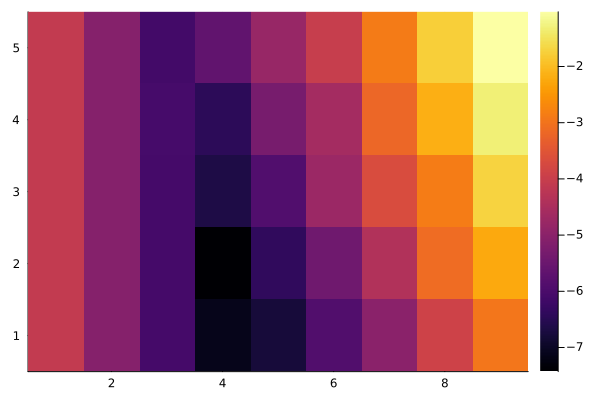

In [9]:
heatmap(log10.(errors))

## Variational differential equation

The variational differential equation with analytic differential $df/dx$ is extemely precise. The error against the complex step derivative reference ranges between $2\text{eps}$ and $10^3\text{eps}$ as $h$ becomes smaller.

In [10]:
x0 = [1.0, 1.0]
x0_aug = augmentStateVariationIv(x0)

errors = zeros(5,1)
for prec in 1:5
    eta, _, _ = rungeKutta(
        (t,x) -> augmentStateVariationRhs(x->model.f(t,x,p0), 
                                     x->model.dfdx(t,x,p0), x, model.nx),
        x0_aug, 0.0, 30.0, 10.0^(-prec), RK4);
    W = reshape(eta[model.nx+1:model.nx*(model.nx+1),end], (model.nx,model.nx))
    errors[prec] = norm(W-W_ref[prec],Inf)
end
    

In [11]:
errors

5×1 Matrix{Float64}:
 1.2212453270876722e-15
 3.1155633628543455e-15
 9.658940314238862e-15
 2.886579864025407e-14
 7.229633558480941e-14

## Continuous adjoint derivative

The continuous adjoint uses an analytic right hand side differential $\lambda^T\frac{\partial f}{\partial x}$. The error is huge for coarse step sizes, and converges to zero as the step size does. The reason is that the RK4 method, like all explicit Runge-Kutta methods, is not self-adjoint.

In [12]:
errors = zeros(5,1)
for prec in 1:5
    h = 10.0^(-prec)
    
    # Solve forward IVP and create an interpolation of the eta approximations
    # The interpolation grid starts at 1 and is unit-spaced
    TNOM, XNOM, _, _ = rungeKuttaTraj((t,x) -> model.f(t,x,p0), x0, 0.0, 30.0, h, RK4);
    XNOM_=[XNOM[:,i] for i in 1:size(XNOM,2)]
    interp_linear = interpolate(XNOM_,BSpline(Linear()))

    eta1, _, _ = rungeKutta(
        (t,lam) -> -model.fadj(t, interp_linear(1+Int64(floor(t/h))), lam, p0),
        [1.0, 0.0], 30.0, 0.0, -h, RK4);

    eta2, _, _ = rungeKutta(
        (t,lam) -> -model.fadj(t, interp_linear(1+Int64(floor(t/h))), lam, p0),
        [0.0, 1.0], 30.0, 0.0, -h, RK4);

    W = hcat(eta1,eta2)'
    errors[prec] = norm(W-W_ref[prec],Inf)
    println(W)
end

[-0.024299267362247606 0.8873732319405094; -0.9226762169534503 0.03401597065319098]
[-0.03295281628770795 0.8840850947198738; -0.9155508042723504 0.03174433306206732]
[-0.03380390135036361 0.883755333025513; -0.9149003771972236 0.03149747484275771]
[-0.03389368491461537 0.8837203600332598; -0.9148322415858083 0.03147136753037419]
[-0.033897936886848216 0.8837187033636826; -0.9148290171268394 0.03147012999122176]


In [13]:
errors

5×1 Matrix{Float64}:
 0.00961692920328324
 0.0009455948464313566
 9.450798640733837e-5
 4.724411884836355e-6
 4.724396289249033e-7

## Discrete adjoint derivative

To implement the discrete adjoint of a Runge-Kutta method, we first of all need to **write to tape** all intermediate quantities computed during the forward solution of the nominal IVP.

The discrete adjoint error much less than the continuous one but around $10$ times higher than the variational differential equation.

In [14]:
errors = zeros(5,1)
for prec in 1:5
    h = 10.0^(-prec)
    tape = rungeKuttaTaping((t,x) -> model.f(t,x,p0), x0, 0.0, 30.0, h, RK4)

    lam1 = rungeKuttaAdjoint( (t,x,lam) -> model.fadj(t,x,lam,p0), [1.0, 0.0], tape) 

    lam2 = rungeKuttaAdjoint( (t,x,lam) -> model.fadj(t,x,lam,p0), [0.0, 1.0], tape) 

    W = hcat(lam1,lam2)'
    errors[prec] = norm(W-W_ref[prec],Inf)
end

In [15]:
errors

5×1 Matrix{Float64}:
 1.1310397063368782e-15
 3.774758283725532e-15
 9.429956815409923e-15
 4.951594689828198e-14
 1.1762812945903534e-13